# Reliability plots for "nudges" data

In [134]:
# read csv into numpy array
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.io import loadmat

# df = pd.read_csv('../data/nudges.csv')
# list(enumerate(df.columns))

mat = loadmat('../data/psych.mat')
data = mat['D'][0,0]

raw_names = data['JournalNames'].flatten()
journal_lookup = [n.item() if hasattr(n, 'item') else n for n in raw_names]

raw_codes = data['JournalTypes']['arr'].item()
journal_codes = raw_codes.flatten().astype(int)

df = pd.DataFrame({
    'tvalues': data['tvalues'].flatten(),
    'df': data['df'].flatten()
})

# calculate 2 sided p values from t values and degrees of freedom
df['p_value'] = 2 * stats.t.sf(np.abs(df['tvalues']), df['df'])

In [121]:
# df['t_stat'] = df['cohens_d'] / np.sqrt(df['variance_d'])
# df['p_value']  = stats.t.cdf(-df['t_stat'], df['n_comparison'] - 2)
# df['p_value']

# subset data to only include rows where p_value < 0.05
significant_df = df[df['p_value'] < 0.025]
# multiply all p values by 40
significant_df['p_value'] = significant_df['p_value'] * 40
len(significant_df)
len(df)

/var/folders/2p/pvl5m11d621fk0xffszjtbw80000gn/T/ipykernel_18983/1138233412.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_df['p_value'] = significant_df['p_value'] * 40


26841

In [303]:
import matplotlib.pyplot as plt
pi_hat_0 = np.mean(df['p_value'] > 0.5) / (1 - 0.5)
pi_hat_0

np.float64(0.2698111098692299)

             p_bin     p_min     p_max    p_mean  count  p_bin_length  \
0  (-0.001, 0.111]  0.000000  0.111010  0.017142  19197      0.111010   
1   (0.111, 0.222]  0.111133  0.222222  0.161447   1567      0.111089   
2   (0.222, 0.333]  0.222347  0.333285  0.275683   1090      0.110937   
3   (0.333, 0.444]  0.333812  0.444372  0.387383    927      0.110560   
4   (0.444, 0.556]  0.444599  0.555244  0.498834    856      0.110645   
5   (0.556, 0.667]  0.555595  0.666654  0.609377    825      0.111058   
6   (0.667, 0.778]  0.666902  0.777741  0.723274    805      0.110839   
7   (0.778, 0.889]  0.777819  0.888847  0.832967    749      0.111027   
8     (0.889, 1.0]  0.889107  1.000000  0.944544    825      0.110893   

   true_nulls_hat  proportion_true_nulls bin_start bin_end  
0      803.934260               0.041878    -0.001   0.111  
1      804.506923               0.513406     0.111   0.222  
2      803.406346               0.737070     0.222   0.333  
3      800.676100        

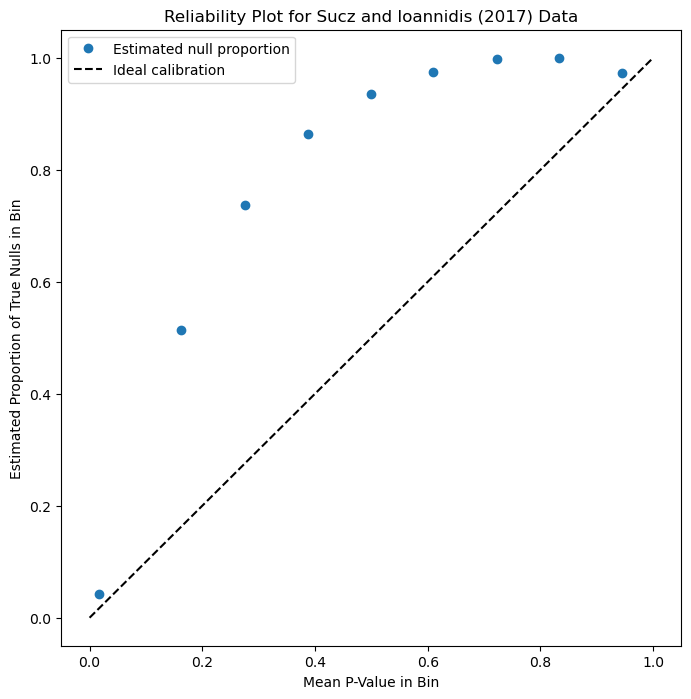

In [296]:
# p-value bins
bins = np.linspace(0, 1, 10)

# put p-values into bins
df["p_bin"] = pd.cut(df["p_value"], bins=bins, include_lowest=True, right=True)

# summarize within each p-bin
p_bin_stats = (
    df.groupby("p_bin", observed=False)
      .agg(
          p_min=("p_value", "min"),
          p_max=("p_value", "max"),
          p_mean=("p_value", "mean"),
          count=("p_value", "size")
      )
      .reset_index()
)

# total number of tests
m = len(df)

# empirical p-range length actually occupied within each bin
p_bin_stats["p_bin_length"] = p_bin_stats["p_max"] - p_bin_stats["p_min"]

# expected number of nulls in that interval under Storey's estimate
p_bin_stats["true_nulls_hat"] = pi_hat_0 * m * p_bin_stats["p_bin_length"]

# estimated proportion of true nulls in each occupied bin
p_bin_stats["proportion_true_nulls"] = np.minimum(
    p_bin_stats["true_nulls_hat"] / p_bin_stats["count"],
    1.0
)

# optional: bin endpoints from the theoretical partition
p_bin_stats["bin_start"] = p_bin_stats["p_bin"].apply(lambda x: x.left)
p_bin_stats["bin_end"] = p_bin_stats["p_bin"].apply(lambda x: x.right)

# drop empty bins or bins where min/max/mean are undefined
p_bin_stats = p_bin_stats.dropna(subset=["p_min", "p_max", "p_mean"])

print(p_bin_stats)

# reliability plot
plt.figure(figsize=(8, 8))

plt.plot(
    p_bin_stats["p_mean"],
    p_bin_stats["proportion_true_nulls"],
    "o",
    label="Estimated null proportion"
)

# optional: vertical dashed red lines at occupied p-range endpoints
# for _, row in p_bin_stats.iterrows():
#     plt.axvline(row["p_min"], color="red", linestyle="--", alpha=0.4)
#     plt.axvline(row["p_max"], color="red", linestyle="--", alpha=0.4)

# 45-degree reference line
plt.plot([0, 1], [0, 1], "k--", label="Ideal calibration")

plt.xlabel("Mean P-Value in Bin")
plt.ylabel("Estimated Proportion of True Nulls in Bin")
plt.title("Reliability Plot for Sucz and Ioannidis (2017) Data")

plt.legend()
plt.show()

## Q-Value Calibration Plot

In [ ]:
# make q-values from p-values
def qvalues(pvals, lam=0.5):
    pvals = np.asarray(pvals)
    m = len(pvals)

    # sort p-values
    order = np.argsort(pvals)
    p_sorted = pvals[order]

    # estimate pi0
    pi0 = np.mean(pvals > lam) / (1 - lam)
    pi0 = min(pi0, 1.0)

    # compute initial q-values (i.e. pFDRs for each p-value)
    qvals = pi0 * m * p_sorted / np.arange(1, m + 1)

    # enforce monotonicity by taking minimum at each step
    qvals = np.minimum.accumulate(qvals[::-1])[::-1]
    qvals = np.minimum(qvals, 1.0)

    # return in original order
    q_original = np.empty_like(qvals)
    q_original[order] = qvals

    return q_original

df['q_value'] = qvalues(df['p_value'])

               q_bin     p_min     p_max    p_mean    q_mean  count  \
0   (-0.001, 0.0256]  0.000000  0.063288  0.012242  0.006187  17879   
1   (0.0256, 0.0513]  0.063335  0.139439  0.094883  0.036369   1818   
2   (0.0513, 0.0769]  0.139557  0.220242  0.177800  0.063568   1045   
3    (0.0769, 0.103]  0.220404  0.305915  0.261521  0.089356    864   
4     (0.103, 0.128]  0.306134  0.396226  0.349585  0.115009    784   
5     (0.128, 0.154]  0.396419  0.491990  0.444058  0.141120    771   
6     (0.154, 0.179]  0.492382  0.593183  0.543042  0.166926    775   
7     (0.179, 0.205]  0.593320  0.699625  0.646405  0.192411    768   
8     (0.205, 0.231]  0.699810  0.813200  0.757698  0.218416    820   
9     (0.231, 0.256]  0.813378  0.933336  0.876465  0.244589    837   
10    (0.256, 0.282]  0.933783  1.000000  0.968700  0.263637    480   
11    (0.282, 0.308]       NaN       NaN       NaN       NaN      0   
12    (0.308, 0.333]       NaN       NaN       NaN       NaN      0   
13    

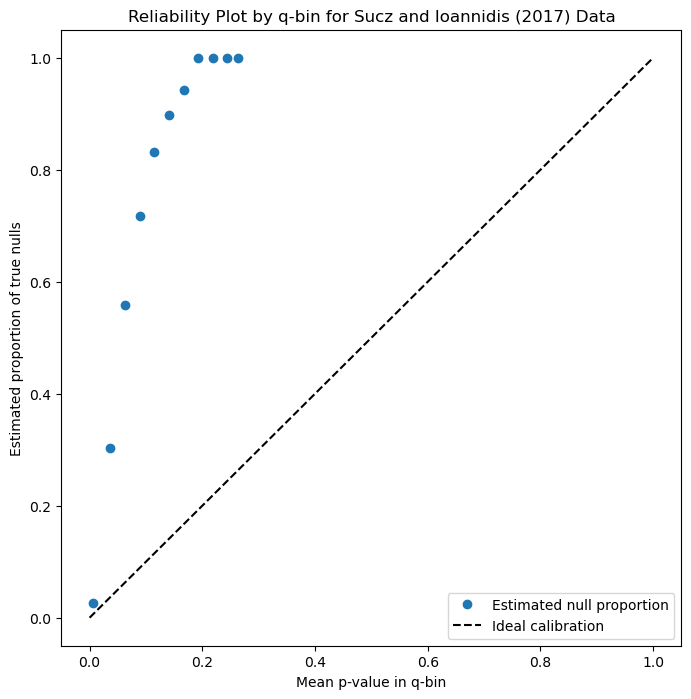

In [ ]:
# q-value bins
bins = np.linspace(0, 1, 40)

# put q-values into bins
df["q_bin"] = pd.cut(df["q_value"], bins=bins, include_lowest=True, right=True)

# summarize p-values within each q-bin
q_bin_stats = (
    df.groupby("q_bin", observed=False)
      .agg(
          p_min=("p_value", "min"),
          p_max=("p_value", "max"),
          p_mean=("p_value", "mean"),
          q_mean=("q_value", "mean"),
          count=("p_value", "size")
      )
      .reset_index()
)

# empirical p-range length induced by each q-bin
q_bin_stats["p_bin_length"] = q_bin_stats["p_max"] - q_bin_stats["p_min"]

# expected number of nulls in that p-interval under Storey's estimate
q_bin_stats["true_nulls_hat"] = pi_hat_0 * m * q_bin_stats["p_bin_length"]

# estimated null proportion within the q-bin
q_bin_stats["proportion_true_nulls"] = np.minimum(
    q_bin_stats["true_nulls_hat"] / q_bin_stats["count"],
    1.0
)

# optional: q-bin endpoints for reference
q_bin_stats["q_bin_start"] = q_bin_stats["q_bin"].apply(lambda x: x.left)
q_bin_stats["q_bin_end"] = q_bin_stats["q_bin"].apply(lambda x: x.right)

print(q_bin_stats)

plt.figure(figsize=(8, 8))

plt.plot(q_bin_stats["q_mean"], q_bin_stats["proportion_true_nulls"], "o", label="Estimated null proportion")

# # add vertical dashed red lines at p_min and p_max
# for _, row in q_bin_stats.iterrows():
#     plt.axvline(row["p_min"], color="red", linestyle="--", alpha=0.4)
#     plt.axvline(row["p_max"], color="red", linestyle="--", alpha=0.4)

# 45-degree reference line
plt.plot([0, 1], [0, 1], "k--", label="Ideal calibration")

plt.xlabel("Mean p-value in q-bin")
plt.ylabel("Estimated proportion of true nulls")
plt.title("Reliability Plot by q-bin for Sucz and Ioannidis (2017) Data")

plt.legend()
plt.show()

## lfdr Calibration Plot

In [280]:
%reload_ext autoreload
%autoreload 2
from npeb import Grenander, local_fdr

In [300]:
# check and see if there are duplicates in the p-values
print(f"Number of unique p-values: {len(df['p_value'].unique())}")
print(f"Total number of p-values: {len(df['p_value'])}")

# show me the distribution of the duplicate p-values
duplicate_pvals = df['p_value'][df['p_value'].duplicated(keep=False)]

# list the unique duplicate p-values and their counts
duplicate_pval_counts = duplicate_pvals.value_counts()
# print(duplicate_pval_counts)

# keep only the unique p-values for Grenander fitting
unique_pvals = df['p_value'].unique()
unique_pvals.sort()
unique_pvals
# remove any p-values that are exactly 0 or 1, since Grenander is defined on (0, 1)
# unique_pvals = unique_pvals[(unique_pvals > 0) & (unique_pvals < 1)]

Number of unique p-values: 20393
Total number of p-values: 26841


array([0.00000000e+000, 1.13289542e-273, 1.58801981e-196, ...,
       9.99226602e-001, 9.99644143e-001, 1.00000000e+000], shape=(20393,))

In [301]:
# select 100 random p values from the data
gren = Grenander(x_min=-0.1, x_max=1.2)
fhat =  gren.fit(unique_pvals)

In [305]:
df['lfdr'] = pi_hat_0 / gren.pdf(df['p_value'].values)

          lfdr_bin     p_min     p_max    p_mean  lfdr_mean  count  \
0  (-0.001, 0.111]  0.000000  0.051319  0.010803   0.063363  17324   
1   (0.111, 0.222]  0.051385  0.074266  0.062160   0.184958    961   
2   (0.222, 0.333]  0.074353  0.100646  0.087058   0.264625    762   
3   (0.333, 0.444]  0.100725  0.142412  0.121805   0.414013    703   
4   (0.444, 0.556]  0.142634  0.178514  0.160804   0.500780    510   
5   (0.556, 0.667]  0.179143  0.237645  0.208402   0.613793    679   
6   (0.667, 0.778]  0.237915  0.343719  0.290485   0.725768   1032   
7   (0.778, 0.889]  0.344234  0.377447  0.362044   0.851459    284   
8     (0.889, 1.0]  0.378223  0.600013  0.488660   0.927665   1736   

   p_bin_length  true_nulls_hat  proportion_true_nulls lfdr_bin_start  \
0      0.051319      371.654698               0.021453         -0.001   
1      0.022881      165.706514               0.172431          0.111   
2      0.026293      190.414278               0.249888          0.222   
3      

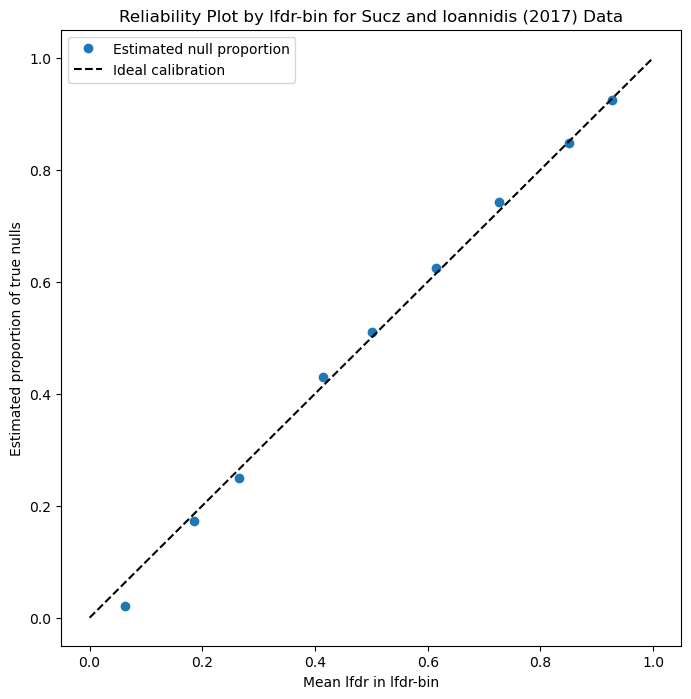

In [306]:
# lfdr bins
bins = np.linspace(0, 1, 10)

# put lfdr  into bins
df["lfdr_bin"] = pd.cut(df["lfdr"], bins=bins, include_lowest=True, right=True)

m = len(df)

# summarize p-values within each q-bin
lfdr_bin_stats = (
    df.groupby("lfdr_bin", observed=False)
      .agg(
          p_min=("p_value", "min"),
          p_max=("p_value", "max"),
          p_mean=("p_value", "mean"),
          lfdr_mean=("lfdr", "mean"),
          count=("p_value", "size")
      )
      .reset_index()
)

# empirical p-range length induced by each q-bin
lfdr_bin_stats["p_bin_length"] = lfdr_bin_stats["p_max"] - lfdr_bin_stats["p_min"]

# expected number of nulls in that p-interval under Storey's estimate
lfdr_bin_stats["true_nulls_hat"] = pi0_hat * m * lfdr_bin_stats["p_bin_length"]

# estimated null proportion within the q-bin
lfdr_bin_stats["proportion_true_nulls"] = np.minimum(
    lfdr_bin_stats["true_nulls_hat"] / lfdr_bin_stats["count"],
    1.0
)

# optional: q-bin endpoints for reference
lfdr_bin_stats["lfdr_bin_start"] = lfdr_bin_stats["lfdr_bin"].apply(lambda x: x.left)
lfdr_bin_stats["lfdr_bin_end"] = lfdr_bin_stats["lfdr_bin"].apply(lambda x: x.right)

print(lfdr_bin_stats)

# plot reliability plot for lfdr bins (estimated null proportion vs. mean lfdr in bin)

plt.figure(figsize=(8, 8))

plt.plot(lfdr_bin_stats["lfdr_mean"], lfdr_bin_stats["proportion_true_nulls"], "o", label="Estimated null proportion")

# 45-degree reference line
plt.plot([0, 1], [0, 1], "k--", label="Ideal calibration")

plt.xlabel("Mean lfdr in lfdr-bin")
plt.ylabel("Estimated proportion of true nulls")
plt.title("Reliability Plot by lfdr-bin for Sucz and Ioannidis (2017) Data")

plt.legend()
plt.show()

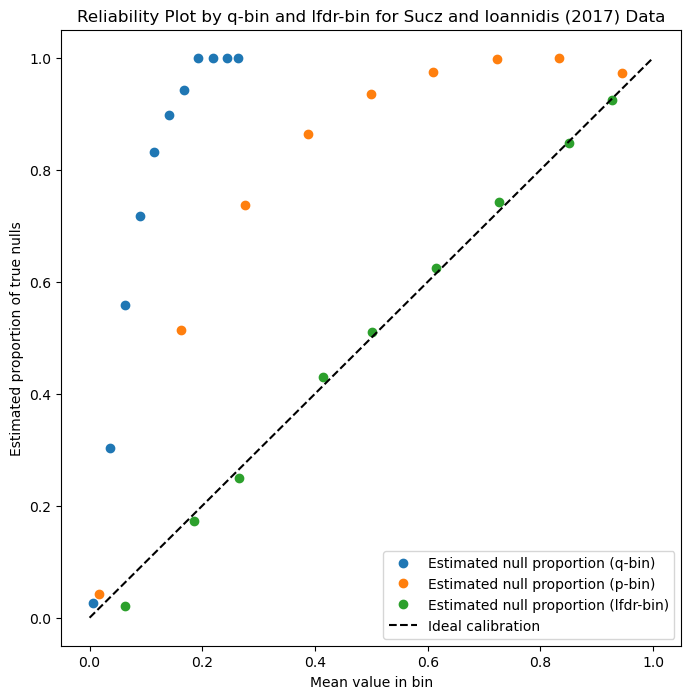

In [310]:
# put all calibration points on one plot
plt.figure(figsize=(8, 8))
plt.plot(q_bin_stats["q_mean"], q_bin_stats["proportion_true_nulls"], "o", label="Estimated null proportion (q-bin)")
plt.plot(p_bin_stats["p_mean"], p_bin_stats["proportion_true_nulls"], "o", label="Estimated null proportion (p-bin)")
plt.plot(lfdr_bin_stats["lfdr_mean"], lfdr_bin_stats["proportion_true_nulls"], "o", label="Estimated null proportion (lfdr-bin)")
# 45-degree reference line
plt.plot([0, 1], [0, 1], "k--", label="Ideal calibration")
plt.xlabel("Mean value in bin")
plt.ylabel("Estimated proportion of true nulls")
plt.title("Reliability Plot by q-bin and lfdr-bin for Sucz and Ioannidis (2017) Data")
plt.legend()
plt.show()